# BioASQ Results Analysis
Static analysis and plots for BM25, Dense, Hybrid, and rerankers (MiniLM, BGE v2).

## 1. Imports and Setup

In [134]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

## 2. Set Input Paths

In [135]:
base_dir = Path.cwd().resolve()
if not (base_dir / "output").exists() and (base_dir.parent / "output").exists():
    # Notebook run from notebooks/ or a subdir
    base_dir = base_dir.parent

print("Base dir:", base_dir)

Base dir: /Users/yun/develop/BioASQ


In [136]:
results = {
    "BM25+RM3": base_dir / "output/eval_bm25_rm3",
    "Dense (MedEmbed)": base_dir / "output/eval_dense_medembed_small",
    "Hybrid (RRF)": base_dir / "output/eval_hybird_production_test",
    "Reranker MiniLM": base_dir / "output/eval_stage2_rerank",
    "BGE v2 (len=200)": base_dir / "output/eval_stage2_rerank_bge_reranker_v2_m3_len200",
    "BGE v2 (len=512)": base_dir / "output/eval_stage2_rerank_bge_reranker_v2_m3_len512",
}

output_dir = base_dir / "output" / "analysis_output"
figures_dir = output_dir / "figures"
output_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(exist_ok=True)

print("Outputs:", output_dir)
print("Methods:", list(results.keys()))

Outputs: /Users/yun/develop/BioASQ/output/analysis_output
Methods: ['BM25+RM3', 'Dense (MedEmbed)', 'Hybrid (RRF)', 'Reranker MiniLM', 'BGE v2 (len=200)', 'BGE v2 (len=512)']


## 3. Load Configuration and Run Metrics

In [137]:
def load_metrics_from_dir(result_dir: Path) -> pd.DataFrame | None:
    result_dir = Path(result_dir)
    metrics_file = result_dir / "rerank_metrics.csv"
    if not metrics_file.exists():
        metrics_file = result_dir / "metrics.csv"
    if metrics_file.exists():
        df = pd.read_csv(metrics_file)
        if "split" not in df.columns and "batch" in df.columns:
            df["split"] = df["batch"]
        return df

    # Hybrid outputs recall-focused tables in results_all.csv
    results_all = result_dir / "results_all.csv"
    if results_all.exists():
        df = pd.read_csv(results_all)
        best_cfg = result_dir / "best_config.json"
        if best_cfg.exists():
            with best_cfg.open("r", encoding="utf-8") as f:
                cfg = json.load(f)
            k_rrf = cfg.get("k_rrf")
            w_bm25 = cfg.get("w_bm25")
            w_dense = cfg.get("w_dense")
            if k_rrf is not None and w_bm25 is not None and w_dense is not None:
                df = df[
                    np.isclose(df["k_rrf"], float(k_rrf))
                    & np.isclose(df["w_bm25"], float(w_bm25))
                    & np.isclose(df["w_dense"], float(w_dense))
                ]
        if "split" not in df.columns and "batch" in df.columns:
            df["split"] = df["batch"]
        return df

    print(f"Missing metrics in {result_dir}")
    return None

all_metrics = {}
for name, result_dir in results.items():
    df = load_metrics_from_dir(result_dir)
    if df is not None and not df.empty:
        all_metrics[name] = df
        print(f"Loaded {name}: {result_dir}")

print("Loaded sets:", len(all_metrics))

Loaded BM25+RM3: /Users/yun/develop/BioASQ/output/eval_bm25_rm3
Loaded Dense (MedEmbed): /Users/yun/develop/BioASQ/output/eval_dense_medembed_small
Loaded Hybrid (RRF): /Users/yun/develop/BioASQ/output/eval_hybird_production_test
Loaded Reranker MiniLM: /Users/yun/develop/BioASQ/output/eval_stage2_rerank
Loaded BGE v2 (len=200): /Users/yun/develop/BioASQ/output/eval_stage2_rerank_bge_reranker_v2_m3_len200
Loaded BGE v2 (len=512): /Users/yun/develop/BioASQ/output/eval_stage2_rerank_bge_reranker_v2_m3_len512
Loaded sets: 6


## 4. Filter and Validate BGE Configs (len=200, len=512)

In [138]:
for bge_len in [200, 512]:
    config_path = base_dir / f"output/eval_stage2_rerank_bge_reranker_v2_m3_len{bge_len}/config.json"
    if not config_path.exists():
        print(f"Missing config for BGE len={bge_len}")
        continue
    with config_path.open("r", encoding="utf-8") as f:
        config = json.load(f)
    model = config.get("model")
    model_max_length = config.get("model_max_length")
    model_batch = config.get("model_batch")
    print(f"BGE len={bge_len}: model={model}, max_length={model_max_length}, batch={model_batch}")
    if model_max_length != bge_len:
        print(f"Warning: expected model_max_length={bge_len}, found {model_max_length}")

BGE len=200: model=BAAI/bge-reranker-v2-m3, max_length=200, batch=512
BGE len=512: model=BAAI/bge-reranker-v2-m3, max_length=512, batch=256


## 5. Consolidate Metrics

In [139]:
rows = []

for method_name, df in all_metrics.items():
    df_copy = df.copy()
    df_copy["method"] = method_name
    rows.append(df_copy)

df_all = pd.concat(rows, ignore_index=True)

if "split" not in df_all.columns:
    raise ValueError("Missing 'split' column after loading metrics.")

def normalize_split(split_name: str) -> str:
    if pd.isna(split_name):
        return split_name
    split_str = str(split_name)
    if split_str.startswith("best_rrf_"):
        split_str = split_str.replace("best_rrf_", "")
        split_str = split_str.replace("_top2000", "")
    return split_str

df_all["split_normalized"] = df_all["split"].apply(normalize_split)

metric_cols = [c for c in df_all.columns if c.startswith("MeanR@")] + ["MAP@10", "GMAP@10", "MRR@10"]
print("Metrics columns:", metric_cols)
print("Splits:", df_all["split_normalized"].unique().tolist())

Metrics columns: ['MeanR@50', 'MeanR@100', 'MeanR@200', 'MeanR@500', 'MeanR@2000', 'MeanR@5000', 'MeanR@1000', 'MeanR@300', 'MeanR@400', 'MeanR@431', 'MeanR@928', 'MeanR@Krec', 'MAP@10', 'GMAP@10', 'MRR@10']
Splits: ['train_subset', '13B1_golden', '13B2_golden', '13B3_golden', '13B4_golden']


## 6. Summary Table - Test Average (13B1-4)

In [140]:
test_splits = ["13B1_golden", "13B2_golden", "13B3_golden", "13B4_golden"]
df_test = df_all[df_all["split_normalized"].isin(test_splits)].copy()

summary_rows = []
for method in df_all["method"].unique():
    method_data = df_test[df_test["method"] == method]
    if method_data.empty:
        continue
    row = {"method": method}
    for col in ["MAP@10", "GMAP@10", "MRR@10", "MeanR@50", "MeanR@100", "MeanR@500", "MeanR@2000"]:
        if col in method_data.columns:
            row[col] = method_data[col].mean()
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows).sort_values("MAP@10", ascending=False)
print(df_summary.round(3).to_string(index=False))

summary_path = output_dir / "summary_test_avg.csv"
df_summary.to_csv(summary_path, index=False)
print("Saved:", summary_path)

          method  MAP@10  GMAP@10  MRR@10  MeanR@50  MeanR@100  MeanR@500  MeanR@2000
BGE v2 (len=512)   0.418    0.175   0.689     0.573      0.672      0.846       0.907
 Reranker MiniLM   0.385    0.144   0.704     0.525      0.622      0.823       0.907
BGE v2 (len=200)   0.351    0.092   0.637     0.499      0.598      0.796       0.907
    Hybrid (RRF)   0.342    0.088   0.636     0.491      0.597      0.784       0.908
        BM25+RM3   0.305    0.044   0.551     0.452      0.533      0.723       0.844
Dense (MedEmbed)   0.207    0.009   0.385     0.381      0.476      0.687       0.829
Saved: /Users/yun/develop/BioASQ/output/analysis_output/summary_test_avg.csv


## 7. Stage 1 Recall Curves - Train and Test Avg
Plot train and test average on the same axes. Use only K values that exist for all three stage-1 methods.

Stage 1 K values (fixed + available): [100, 200, 500, 2000, 5000]
Saved: /Users/yun/develop/BioASQ/output/analysis_output/figures/01_stage1_recall_train_test.png


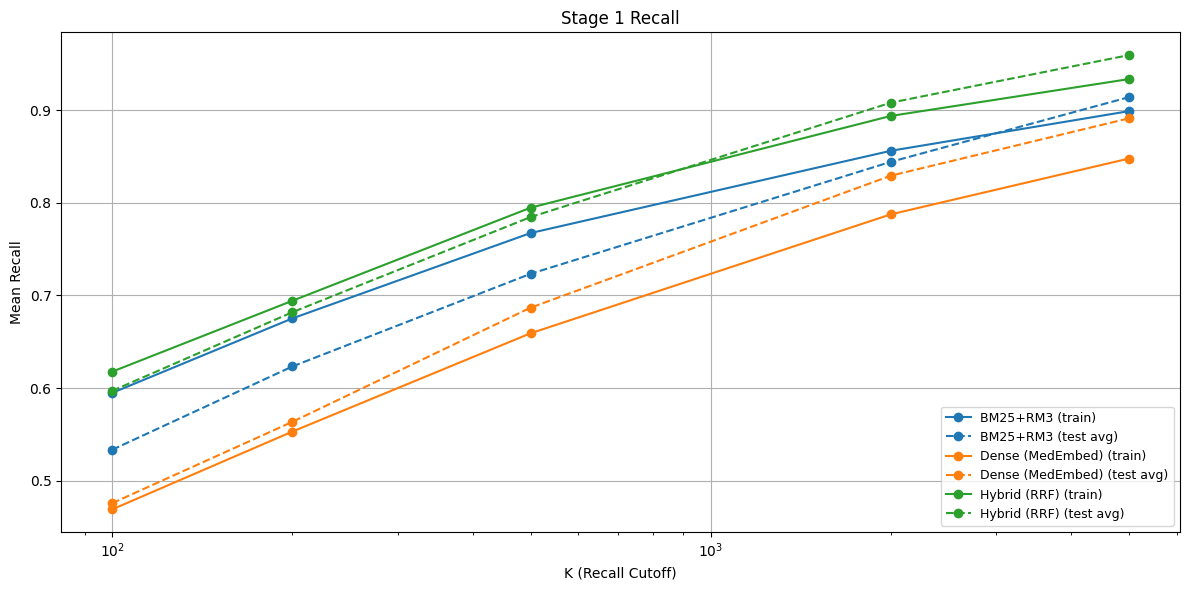

In [144]:
df_train = df_all[df_all["split_normalized"] == "train_subset"].copy()

test_splits = ["13B1_golden", "13B2_golden", "13B3_golden", "13B4_golden"]
df_test = df_all[df_all["split_normalized"].isin(test_splits)].copy()

stage1_methods = ["BM25+RM3", "Dense (MedEmbed)", "Hybrid (RRF)"]

# Use a fixed K list shared across methods.
fixed_k = [100, 200, 500, 2000, 5000]

# Keep only K values that are present and non-NaN for every method in train and test.
valid_k = []
for k in fixed_k:
    col = f"MeanR@{k}"
    ok = True
    for method in stage1_methods:
        method_train = df_train[df_train["method"] == method]
        method_test = df_test[df_test["method"] == method]
        if method_train.empty or method_test.empty:
            ok = False
            break
        train_val = method_train.iloc[0].get(col)
        test_val = method_test[col].mean() if col in method_test.columns else np.nan
        if pd.isna(train_val) or pd.isna(test_val):
            ok = False
            break
    if ok:
        valid_k.append(k)

k_list = valid_k
if not k_list:
    raise ValueError("No overlapping MeanR@K columns found for stage-1 methods.")

print("Stage 1 K values (fixed + available):", k_list)

colors = {
    "BM25+RM3": "#1f77b4",
    "Dense (MedEmbed)": "#ff7f0e",
    "Hybrid (RRF)": "#2ca02c",
}

fig, ax = plt.subplots()
for method in stage1_methods:
    train_row = df_train[df_train["method"] == method]
    test_rows = df_test[df_test["method"] == method]
    if train_row.empty or test_rows.empty:
        continue
    train_row = train_row.iloc[0]
    train_vals = [train_row.get(f"MeanR@{k}", np.nan) for k in k_list]
    test_vals = [test_rows[f"MeanR@{k}"].mean() for k in k_list]

    color = colors.get(method)
    ax.plot(k_list, train_vals, marker="o", label=f"{method} (train)", color=color)
    ax.plot(k_list, test_vals, marker="o", linestyle="--", label=f"{method} (test avg)", color=color)

ax.set_xlabel("K (Recall Cutoff)")
ax.set_ylabel("Mean Recall")
ax.set_title("Stage 1 Recall")
ax.set_xscale("log")
ax.legend(fontsize=9, loc="lower right")

fig_path = figures_dir / "01_stage1_recall_train_test.png"
plt.tight_layout()
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 8. Hybrid vs Reranker Recall
Compare reranker recall gains at small K (50/100/200) and large K (2000) against the Hybrid baseline.

Hybrid/Reranker K values (test): [50, 100, 200, 2000]
Saved: /Users/yun/develop/BioASQ/output/analysis_output/figures/02_hybrid_reranker_recall_map10_test.png


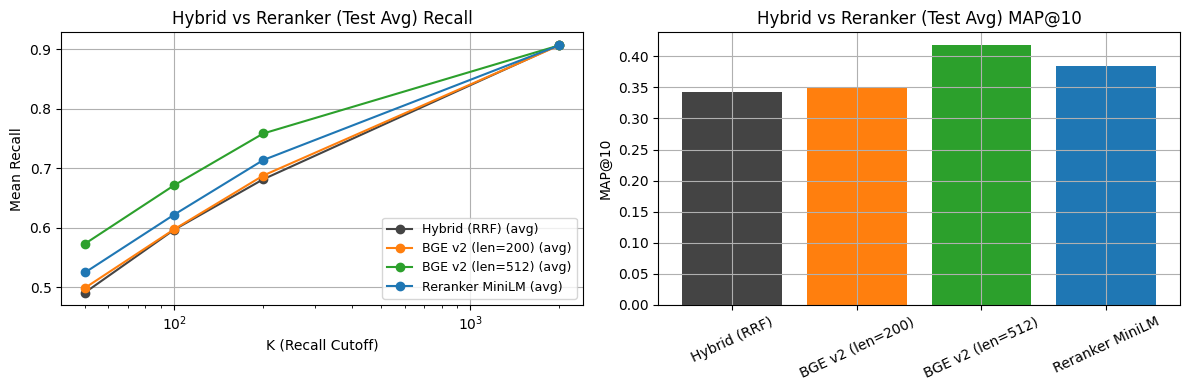

Hybrid/Reranker K values (train): [50, 100, 200, 2000]
Saved: /Users/yun/develop/BioASQ/output/analysis_output/figures/02_hybrid_reranker_recall_map10_train.png


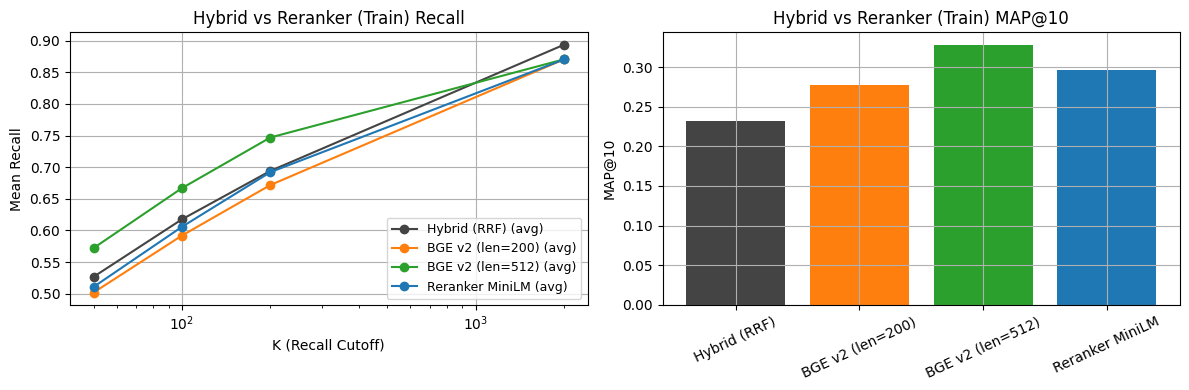

,method,delta@50,delta@100,delta@200,delta@2000
0,BGE v2 (len=200),0.007801,0.000730,0.006258,-0.00096
1,BGE v2 (len=512),0.082011,0.074695,0.076956,-0.00096
2,Reranker MiniLM,0.033684,0.025346,0.032280,-0.00096


In [12]:
df_test = df_all[df_all["split_normalized"].isin(["13B1_golden", "13B2_golden", "13B3_golden", "13B4_golden"])].copy()
df_train = df_all[df_all["split_normalized"] == "train_subset"].copy()

test_avg = df_test.groupby("method").mean(numeric_only=True)
train_avg = df_train.groupby("method").mean(numeric_only=True)

baseline_method = "Hybrid (RRF)"
reranker_methods = [
    m for m in test_avg.index
    if m.startswith("Reranker") or m.startswith("BGE v2")
]

colors = {
    baseline_method: "#444444",
    "Reranker MiniLM": "#1f77b4",
    "BGE v2 (len=200)": "#ff7f0e",
    "BGE v2 (len=512)": "#2ca02c",
    "BGE v2 (len=1024)": "#d62728",
}

k_candidates = [50, 100, 200, 2000]


def _build_compare_methods(avg_df):
    compare = []
    if baseline_method in avg_df.index:
        compare.append(baseline_method)
    compare.extend([m for m in reranker_methods if m in avg_df.index])
    return compare


def _build_k_list(avg_df, compare):
    k_values = []
    for k in k_candidates:
        col = f"MeanR@{k}"
        if col not in avg_df.columns:
            continue
        if avg_df.loc[compare, col].isna().all():
            continue
        k_values.append(k)
    return k_values


def _plot_recall_map(avg_df, compare, k_list, title_prefix, fig_path):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ax_recall = axes[0]
    for method in compare:
        values = [avg_df.loc[method, f"MeanR@{k}"] for k in k_list]
        ax_recall.plot(
            k_list,
            values,
            marker="o",
            label=f"{method} (avg)",
            color=colors.get(method),
        )

    ax_recall.set_xlabel("K (Recall Cutoff)")
    ax_recall.set_ylabel("Mean Recall")
    ax_recall.set_title(f"{title_prefix} Recall")
    ax_recall.set_xscale("log")
    ax_recall.legend(fontsize=9, loc="lower right")

    ax_map = axes[1]
    map_values = [avg_df.loc[method, "MAP@10"] for method in compare]
    bar_colors = [colors.get(method) for method in compare]
    ax_map.bar(compare, map_values, color=bar_colors)
    ax_map.set_ylabel("MAP@10")
    ax_map.set_title(f"{title_prefix} MAP@10")
    ax_map.tick_params(axis="x", rotation=25)

    plt.tight_layout()
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    print("Saved:", fig_path)
    plt.show()


compare_test = _build_compare_methods(test_avg)
k_list_test = _build_k_list(test_avg, compare_test)
if not k_list_test:
    raise ValueError("No overlapping MeanR@K columns found for hybrid/reranker recall plot (test).")

print("Hybrid/Reranker K values (test):", k_list_test)
_plot_recall_map(
    test_avg,
    compare_test,
    k_list_test,
    "Hybrid vs Reranker (Test Avg)",
    figures_dir / "02_hybrid_reranker_recall_map10_test.png",
)

compare_train = _build_compare_methods(train_avg)
k_list_train = _build_k_list(train_avg, compare_train)
if not k_list_train:
    raise ValueError("No overlapping MeanR@K columns found for hybrid/reranker recall plot (train).")

print("Hybrid/Reranker K values (train):", k_list_train)
_plot_recall_map(
    train_avg,
    compare_train,
    k_list_train,
    "Hybrid vs Reranker (Train)",
    figures_dir / "02_hybrid_reranker_recall_map10_train.png",
)

# Delta vs hybrid baseline to emphasize small-K gains (test only).
reranker_recall_rows = []
if baseline_method in test_avg.index:
    baseline = test_avg.loc[baseline_method]
    for method in reranker_methods:
        if method not in test_avg.index:
            continue
        row = {"method": method}
        for k in k_list_test:
            col = f"MeanR@{k}"
            base_val = baseline.get(col)
            method_val = test_avg.loc[method, col]
            if pd.isna(base_val) or pd.isna(method_val):
                row[f"delta@{k}"] = np.nan
            else:
                row[f"delta@{k}"] = method_val - base_val
        reranker_recall_rows.append(row)

reranker_recall_df = pd.DataFrame(reranker_recall_rows)
if not reranker_recall_df.empty:
    display(reranker_recall_df)

## 9. Per-split Recall Stability
Show per-split MeanR@200 and MeanR@500 for Hybrid vs rerankers to spot unstable batches.

Saved: /Users/yun/develop/BioASQ/output/analysis_output/figures/03_per_split_meanr_200.png


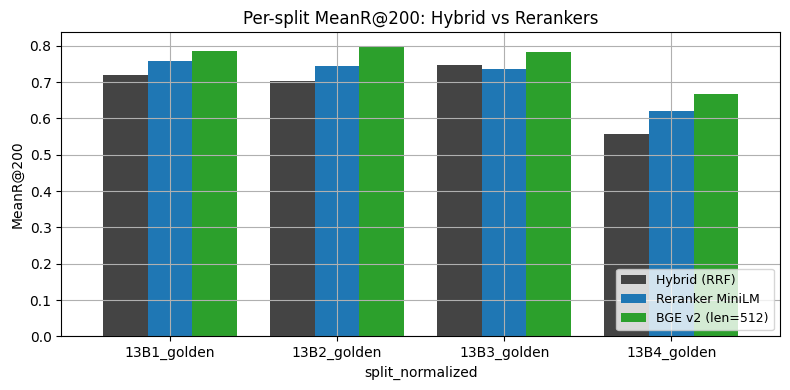

Saved: /Users/yun/develop/BioASQ/output/analysis_output/figures/03_per_split_meanr_500.png


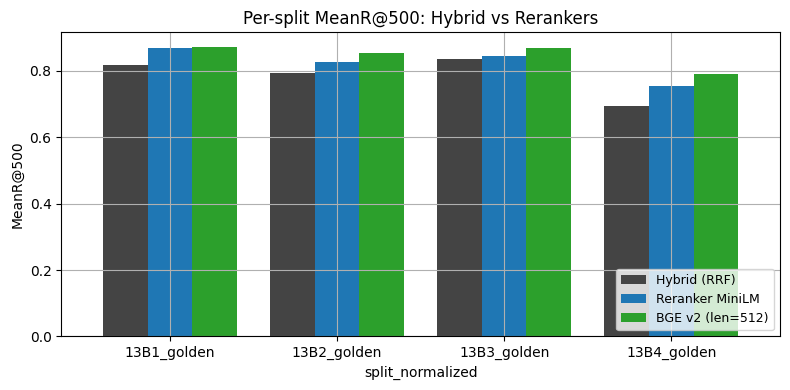

In [13]:
split_order = ["13B1_golden", "13B2_golden", "13B3_golden", "13B4_golden"]
method_order = ["Hybrid (RRF)", "Reranker MiniLM", "BGE v2 (len=512)"]

plot_df = df_all[
    df_all["split_normalized"].isin(split_order)
    & df_all["method"].isin(method_order)
].copy()

if plot_df.empty:
    raise ValueError("No rows found for per-split stability plot.")

colors = {
    "Hybrid (RRF)": "#444444",
    "Reranker MiniLM": "#1f77b4",
    "BGE v2 (len=512)": "#2ca02c",
}

for metric in ["MeanR@200", "MeanR@500"]:
    if metric not in plot_df.columns:
        raise ValueError(f"Missing column: {metric}")

    pivot = plot_df.pivot_table(
        index="split_normalized",
        columns="method",
        values=metric,
        aggfunc="mean",
    ).reindex(split_order)

    fig, ax = plt.subplots(figsize=(8, 4))
    pivot[method_order].plot(
        kind="bar",
        ax=ax,
        color=[colors.get(m) for m in method_order],
        width=0.8,
    )

    ax.set_ylabel(metric)
    ax.set_title(f"Per-split {metric}: Hybrid vs Rerankers")
    ax.legend(fontsize=9, loc="lower right")
    ax.tick_params(axis="x", rotation=0)

    fig_path = figures_dir / f"03_per_split_{metric.lower().replace('@', '_')}.png"
    plt.tight_layout()
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    print("Saved:", fig_path)
    plt.show()

## 11. Type and Length Effects
Compute per-query Recall@200/500 and MAP@10 by question type and length (word count) for train vs test.

In [ ]:
import json
import re
from pathlib import Path

train_split = "train_subset"
test_splits = ["13B1_golden", "13B2_golden", "13B3_golden", "13B4_golden"]

qrels_paths = {
    "train_subset": base_dir / "example" / "training14b_10pct_sample.json",
    "13B1_golden": base_dir / "bioasq_data" / "Task13BGoldenEnriched" / "13B1_golden.json",
    "13B2_golden": base_dir / "bioasq_data" / "Task13BGoldenEnriched" / "13B2_golden.json",
    "13B3_golden": base_dir / "bioasq_data" / "Task13BGoldenEnriched" / "13B3_golden.json",
    "13B4_golden": base_dir / "bioasq_data" / "Task13BGoldenEnriched" / "13B4_golden.json",
}

run_dirs = {
    "Hybrid (RRF)": base_dir / "output" / "eval_hybird_production_test" / "runs",
    "Reranker MiniLM": base_dir / "output" / "eval_stage2_rerank_minitest" / "runs",
    "BGE v2 (len=512)": base_dir / "output" / "eval_stage2_rerank_bge_reranker_v2_m3_len512" / "runs",
}

run_template = "best_rrf_{split}_top2000.tsv"


def _extract_pmid(doc_entry):
    if isinstance(doc_entry, dict):
        doc_entry = doc_entry.get("document", "")
    if not isinstance(doc_entry, str):
        return None
    if "/" in doc_entry:
        return doc_entry.rsplit("/", 1)[-1]
    return doc_entry


def _load_questions_meta(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    meta = {}
    for q in data.get("questions", []):
        qid = q.get("id")
        body = q.get("body") or ""
        qtype = (q.get("type") or "unknown").lower()
        word_count = len(re.findall(r"\w+", body))
        meta[qid] = {"type": qtype, "len_words": word_count}
    return meta


def _load_qrels(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    qrels = {}
    for q in data.get("questions", []):
        qid = q.get("id")
        docs = q.get("documents", [])
        pmids = {
            _extract_pmid(d)
            for d in docs
            if _extract_pmid(d)
        }
        if qid:
            qrels[qid] = pmids
    return qrels


def _load_run(path):
    df = pd.read_csv(path, sep="\t")
    cols = {c.lower(): c for c in df.columns}
    qid_col = cols.get("qid")
    doc_col = cols.get("docno") or cols.get("docid") or cols.get("doc")
    rank_col = cols.get("rank")
    if qid_col is None or doc_col is None:
        raise ValueError(f"Missing qid/doc columns in {path}")
    df[qid_col] = df[qid_col].astype(str)
    df[doc_col] = df[doc_col].astype(str)
    if rank_col:
        df = df.sort_values([qid_col, rank_col])
    return df[[qid_col, doc_col]]


def _ap_at_k(docs, rels, k=10):
    if not rels:
        return 0.0
    hits = 0
    score = 0.0
    for i, doc in enumerate(docs[:k], start=1):
        if doc in rels:
            hits += 1
            score += hits / i
    return score / len(rels)


def _compute_metrics(run_df, qrels, k_values=(200, 500), ap_k=10):
    qid_col, doc_col = run_df.columns.tolist()
    metrics = []
    for qid, group in run_df.groupby(qid_col, sort=False):
        rels = qrels.get(qid, set())
        if not rels:
            continue
        docs = group[doc_col].tolist()
        row = {"qid": qid, "MAP@10": _ap_at_k(docs, rels, ap_k)}
        for k in k_values:
            top_docs = docs[:k]
            hit = len(set(top_docs) & rels)
            row[f"Recall@{k}"] = hit / len(rels)
        metrics.append(row)
    return metrics


meta_by_split = {s: _load_questions_meta(p) for s, p in qrels_paths.items()}
qrels_by_split = {s: _load_qrels(p) for s, p in qrels_paths.items()}

records = []
for split, qrels in qrels_by_split.items():
    meta = meta_by_split.get(split, {})
    for method, run_dir in run_dirs.items():
        run_path = run_dir / run_template.format(split=split)
        if not run_path.exists():
            print(f"Missing run: {run_path}")
            continue
        run_df = _load_run(run_path)
        metrics = _compute_metrics(run_df, qrels)
        for row in metrics:
            info = meta.get(row["qid"], {"type": "unknown", "len_words": np.nan})
            records.append(
                {
                    "split": split,
                    "method": method,
                    "qid": row["qid"],
                    "type": info.get("type", "unknown"),
                    "len_words": info.get("len_words", np.nan),
                    "MAP@10": row["MAP@10"],
                    "Recall@200": row.get("Recall@200"),
                    "Recall@500": row.get("Recall@500"),
                }
            )

if not records:
    raise ValueError("No per-query records created. Check run paths and qrels.")

per_query_df = pd.DataFrame(records)
print("Per-query rows:", len(per_query_df))

# ---- Type breakdown ----
qtype_order = ["yesno", "factoid", "list", "summary", "unknown"]
extra_types = sorted(t for t in per_query_df["type"].unique() if t not in qtype_order)
qtype_order.extend(extra_types)


def _type_summary(df):
    return (
        df.groupby(["method", "type"], as_index=False)
        .agg(
            n=("qid", "count"),
            MAP@10=("MAP@10", "mean"),
            Recall@200=("Recall@200", "mean"),
            Recall@500=("Recall@500", "mean"),
        )
    )


def _plot_type_bars(summary_df, title_prefix, fig_path):
    metrics = ["Recall@200", "MAP@10"]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric in zip(axes, metrics):
        pivot = summary_df.pivot_table(
            index="type",
            columns="method",
            values=metric,
            aggfunc="mean",
        ).reindex(qtype_order)
        pivot.plot(kind="bar", ax=ax)
        ax.set_ylabel(metric)
        ax.set_title(f"{title_prefix} {metric}")
        ax.tick_params(axis="x", rotation=25)
    plt.tight_layout()
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    print("Saved:", fig_path)
    plt.show()

train_type = _type_summary(per_query_df[per_query_df["split"] == train_split])
test_type = _type_summary(per_query_df[per_query_df["split"].isin(test_splits)])

print("Train type summary (head):")
print(train_type.head().round(3).to_string(index=False))
print("Test type summary (head):")
print(test_type.head().round(3).to_string(index=False))

_plot_type_bars(
    train_type,
    "Train",
    figures_dir / "05_type_train_recall_map10.png",
)
_plot_type_bars(
    test_type,
    "Test Avg",
    figures_dir / "05_type_test_recall_map10.png",
)

# ---- Length breakdown ----
len_values = per_query_df["len_words"].dropna().astype(int)
if len_values.empty:
    raise ValueError("No length values available.")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(len_values, bins=40, color="#4c72b0", alpha=0.8)
ax.set_xlabel("Question length (words)")
ax.set_ylabel("Count")
ax.set_title("Question Length Distribution")
fig_path = figures_dir / "05_length_distribution.png"
plt.tight_layout()
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

per_query_df = per_query_df.copy()
per_query_df["len_bin"] = pd.qcut(per_query_df["len_words"], q=4, duplicates="drop")
per_query_df["len_bin"] = per_query_df["len_bin"].astype(str)

len_order = sorted(per_query_df["len_bin"].unique())


def _len_summary(df):
    return (
        df.groupby(["method", "len_bin"], as_index=False)
        .agg(
            n=("qid", "count"),
            MAP@10=("MAP@10", "mean"),
            Recall@200=("Recall@200", "mean"),
            Recall@500=("Recall@500", "mean"),
        )
    )


def _plot_len_bars(summary_df, title_prefix, fig_path):
    metrics = ["Recall@200", "MAP@10"]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric in zip(axes, metrics):
        pivot = summary_df.pivot_table(
            index="len_bin",
            columns="method",
            values=metric,
            aggfunc="mean",
        ).reindex(len_order)
        pivot.plot(kind="bar", ax=ax)
        ax.set_ylabel(metric)
        ax.set_title(f"{title_prefix} {metric}")
        ax.tick_params(axis="x", rotation=25)
    plt.tight_layout()
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    print("Saved:", fig_path)
    plt.show()

train_len = _len_summary(per_query_df[per_query_df["split"] == train_split])
test_len = _len_summary(per_query_df[per_query_df["split"].isin(test_splits)])

_plot_len_bars(
    train_len,
    "Train",
    figures_dir / "05_length_train_recall_map10.png",
)
_plot_len_bars(
    test_len,
    "Test Avg",
    figures_dir / "05_length_test_recall_map10.png",
)

# Delta table vs overall mean (test only).
overall_test = (
    per_query_df[per_query_df["split"].isin(test_splits)]
    .groupby("method", as_index=False)
    .agg(
        MAP@10=("MAP@10", "mean"),
        Recall@200=("Recall@200", "mean"),
        Recall@500=("Recall@500", "mean"),
    )
)

len_delta = test_len.merge(overall_test, on="method", suffixes=("", "_overall"))
for metric in ["MAP@10", "Recall@200", "Recall@500"]:
    len_delta[f"delta_{metric}"] = len_delta[metric] - len_delta[f"{metric}_overall"]

print("Length delta vs overall (test):")
print(len_delta[["method", "len_bin", "delta_MAP@10", "delta_Recall@200", "delta_Recall@500"]].round(3).to_string(index=False))